# Análisis discriminante para clasificación

Este notebook resuelve un caso ficticio y fácil de seguir: una planta fabrica piezas metalicas y quiere anticipar si cada pieza será **Conforme**, requerira **Retrabajo** o terminará como **Rechazo**.

El objetivo didáctico es aprendercomo funcióna el análisis discriminante lineal, como entrenarlo con `scikit-learn`, como leer sus resultados y como detectar sus errores principales.

**Nivel:** principiante.  
**Datos:** simulados dentro del notebook.  
**Software:** Python, pandas, matplotlib, seaborn y scikit-learn.  
**Equipo:** Google Colab con CPU; no requiere GPU ni archivos externos.

Para correrlo en Colab:

1. Abra https://colab.research.google.com/.
2. Suba este archivo `.ipynb`.
3. Seleccione **Entorno de ejecución -> Ejecutar todas**.
4. Lea la explicacion antes de cada bloque y la interpretacion después de cada resultado.

## Contexto del problema

Imagine una línea de manufactura donde se producen piezas metalicas. Al terminar cada
pieza se registran tres mediciónes sencillas del proceso:

| Medicion | Qué representa |
|---|---|
| Temperatura | Temperatura promedio de la máquina durante el ciclo |
| Vibración | Vibración promedio del equipo |
| Tiempo de ciclo | Tiempo que tardó la pieza en producirse |

Después, el área de calidad revisa la pieza y asigna una de tres clases:

| Clase | Significado simple |
|---|---|
| Conforme | La pieza cumple |
| Retrabajo | La pieza podría corregirse |
| Rechazo | La pieza no debe liberarse |

La pregunta del ejercicio es:

**Con solo esas tres mediciónes, podemos estimar a que clase pertenece una pieza?**

Cómo es un ejemplo para aprender, los datos son sintéticos. Eso significa que los
inventamos de forma controlada para que el notebook sea reproducible. En una planta
real, estos datos vendrían del sistema de producción y de la inspección de calidad.

## La técnica en palabras simples

El **análisis discriminante lineal**, o **LDA** por sus siglas en inglés, es una técnica
de clasificación. Clasificar significa asignar una etiqueta a una observacion.

En este caso, cada pieza tiene tres numeros:

- temperatura
- vibración
- tiempo de ciclo

Y queremos que el modelo elija una de tres etiquetas:

- Conforme
- Retrabajo
- Rechazo

La idea de LDA es sencilla:

1. Mira las piezas históricas de cada clase.
2. Aprende el perfil promedio de cada clase.
3. Busca una combinacion de variables que separe lo mejor posible esas clases.
4. Para una pieza nueva, calcula a que perfil se parece más.

Una forma intuitiva de verlo es como dibujar fronteras entre grupos. Si una pieza cae
cerca del grupo de Rechazo, el modelo la clasificara como Rechazo. Si cae cerca del
grupo Conforme, la clasificara como Conforme.

LDA funcióna mejor cuando las clases tienen formás parecidas y se pueden separar de
manera aproximadamente lineal. Para principiantes, lo importante es recordar esto:

**LDA aprende diferencias entre grupos y usa esas diferencias para clasificar casos nuevos.**

## Un poco de historia

La version clasica del análisis discriminante lineal se asocia con el estadístico
británico **R. A. Fisher**. Fisher publico en **1936** el articulo *The use of
multiple measurements in taxonomic problems*, donde mostro como combinar varias
mediciónes para separar grupos. El ejemplo histórico más conocido usa flores Iris:
con medidas de pétalos y sépalos, se buscaba distinguir especies.

Aunque el origen esta en biología y taxonomía, la idea se adapto a muchos campos:
medicina, crédito, calidad, manufactura, mercadotecnia, educacion y analitica de
clientes. El principio es el mismo: tenemos casos históricos con variables numéricas
y una clase conocida, y queremos aprender una regla para clasificar casos nuevos.

En lenguaje actual, LDA es un modelo supervisado clasico. "Supervisado" significa que
durante el entrenamiento si conocemos la respuesta correcta. En este ejercicio, la
respuesta correcta histórica es `calidad`: Conforme, Retrabajo o Rechazo.

Fuente histórica: Fisher, R. A. (1936), *The use of multiple measurements in taxonomic
problems*, Annals of Eugenics, 7, 179-188. DOI:
https://doi.org/10.1111/j.1469-1809.1936.tb02137.x.

## Cuando conviene usar LDA

LDA suele ser una buena opción cuando el problema tiene estas caracteristicas:

1. **La respuesta es una categoria.** Por ejemplo: bueno/malo, conforme/retrabajo/rechazo,
   cliente alto/medio/bajo riesgo, paciente sano/en observacion/con alerta.
2. **Las entradas son numéricas.** LDA trabaja naturalmente con mediciónes como
   temperatura, presion, vibración, edad, monto, tiempo, dimensiones o indicadores.
3. **Queremos un modelo relativamente fácil de explicar.** LDA permite ver medias por
   grupo, fronteras lineales, probabilidades y una visualizacion con ejes discriminantes.
4. **Hay varias clases.** LDA maneja más de dos clases sin tener que entrenar muchos
   modelos separados.
5. **Los grupos tienen cierta separación.** No necesita separación perfecta, pero si las
   clases están totalmente mezcladas, ningun clasificador sencillo resolvera bien.
6. **Buscamos una primera línea base seria.** En muchos proyectos conviene probar LDA
   antes de modelos más complejos, porque es rápido, estable y fácil de comunicar.

Ejemplos donde puede usarse:

- Clasificar piezas como Conforme, Retrabajo o Rechazo.
- Priorizar inspección de lotes segun mediciónes de proceso.
- Clasificar clientes por nivel de riesgo con variables numéricas.
- Distinguir tipos de falla a partir de sensores.
- Separar grupos medicos usando resultados de laboratorio.

## Cuando NO conviene usarlo como primera opción

LDA puede quedarse corto en estos casos:

1. **Las relaciones son muy curvas o complejas.** LDA traza fronteras lineales; si la
   separación necesita curvas fuertes, otros modelos pueden funciónar mejor.
2. **Hay muchos valores extremos.** Datos atipicos fuertes pueden mover promedios y
   afectar la separación.
3. **Hay variables principalmente categoricas o texto.** Se puede adaptar con
   transformaciones, pero ya no es el caso natural de LDA.
4. **Las clases cambian con el tiempo.** Si la máquina, producto o criterio de calidad
   cambia, el modelo aprendido con datos viejos puede fallar.
5. **El costo del error es alto y no esta definido.** Antes de usarlo para decisiónes
   automáticas, calidad debe acordar que errores son aceptables y validar con datos reales.

## Qué hace LDA por dentro, sin matemáticas pesadas

Pensemos que cada pieza es un punto. Si usamos temperatura, vibración y tiempo de ciclo,
cada pieza tiene tres coordenadas. Cómo dibujar tres dimensiones no siempre es comodo,
LDA busca una manera de combinar esas mediciónes para que los grupos se vean lo más
separados posible.

De forma simple, LDA hace esto:

1. **Calcula el centro de cada clase.** Por ejemplo, el promedio de temperatura,
   vibración y tiempo de las piezas Conformes.
2. **Mide la dispersion dentro de cada clase.** No basta saber el promedio; también
   importa que tan regados están los datos.
3. **Busca una direccion que separe mucho entre clases y mezcle poco dentro de cada clase.**
   Esa direccion es una combinacion de variables.
4. **Coloca una pieza nueva cerca del grupo más probable.** Si su perfil se parece más
   a Rechazo, la predice como Rechazo; si se parece más a Conforme, la predice como Conforme.

Una analogia sencilla: imagine tres nubes de puntos en una mesa. LDA gira la mirada para
ver las nubes desde el angulo donde se separan mejor. Luego usa esa vista para decidir
a que nube pertenece una pieza nueva.

Hay tres palabras que aparecen mucho:

- **Clase:** la categoria que queremos predecir.
- **Variable:** una medición que usamos para predecir.
- **Frontera:** línea imaginaria que separa regiones de decisión.

En scikit-learn, `LinearDiscriminantAnalysis()` se encarga de hacer esos calculos.
Nosotros nos concentramos en preparar datos, entrenar, evaluar y explicar resultados.

## 1. Preparar bibliotecas

Este bloque carga las bibliotecas que usaremos. Si Colab no tiene alguna, la instala.

- `numpy` ayuda a crear datos numéricos.
- `pandas` maneja tablas.
- `matplotlib` y `seaborn` crean gráficas.
- `scikit-learn` contiene el modelo LDA y las métricas.

La variable `faltantes` revisa si falta alguna biblioteca. Si no falta nada, el bloque
solo confirma que podemos continuar.

Qué debe observar el principiante:

- Esta celda no entrena ningun modelo.
- Solo prepara el entorno para que los siguientes bloques funciónen.
- Si aparece "Bibliotecas listas", el notebook ya tiene lo necesario.
- Si Colab instala paquetes, puede tardar unos segundos la primera vez.

In [ ]:
import importlib.util
import subprocess
import sys

paquetes = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}

faltantes = [paquete for modulo, paquete in paquetes.items()
             if importlib.util.find_spec(modulo) is None]

if faltantes:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *faltantes])

print("Bibliotecas listas. Podemos continuar.")

Bibliotecas listas. Podemos continuar.


## 2. Importar herramientas y definir parametros

Aquí importamos las herramientas especificas que usaremos durante todo el ejercicio.

También definimos tres parametros importantes:

- `SEMILLA`: hace que los datos simulados salgan igual cada vez que ejecutamos.
- `CLASES`: fija el orden de las tres clases.
- `CARPETA`: lugar donde se guardaran resultados y gráficas.

La función `guardar_figura` evita repetir código cada vez que hagamos una gráfica.

Qué entra a este bloque:

- No entra ningun dato todavia.
- Solo importamos herramientas.

Qué sale de este bloque:

- Una semilla para repetir el ejercicio.
- Una lista ordenada de clases.
- Una carpeta donde se guardaran archivos.
- Una función para guardar gráficas.

Este bloque es como preparar la mesa antes de cocinar: todavia no analizamos piezas,
pero dejamos listas las herramientas.

In [ ]:
from pathlib import Path
import json
import platform
import shutil

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn
from IPython.display import Markdown, display
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEMILLA = 42
CLASES = ["Conforme", "Retrabajo", "Rechazo"]
COLORES = {"Conforme": "#167D9A", "Retrabajo": "#DA9C20", "Rechazo": "#C24E56"}
CARPETA = Path("resultados_lda_manufactura_principiantes")
CARPETA.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

def guardar_figura(nombre):
    plt.gcf().savefig(CARPETA / f"{nombre}.png", dpi=160, bbox_inches="tight")
    plt.show()

print("Version de scikit-learn:", sklearn.__version__)
print("Carpeta de resultados:", CARPETA.resolve())

Version de scikit-learn: 1.9.0
Carpeta de resultados: C:\Users\baldemar.garza\OneDrive - Xignux Corp\Documentos\ChatGPT\New project\output\analisis_discriminante_manufactura\resultados_lda_manufactura_principiantes


## 3. Crear datos simulados

En un proyecto real cargariamos datos históricos con `pd.read_csv`. Cómo este es un
ejercicio autocontenido, vamos a simular 600 piezas.

La simulacion usa perfiles sencillos:

- Las piezas conformes tienden a tener menor vibración y tiempos normales.
- Las piezas de retrabajo tienden a tener vibración un poco más alta.
- Las piezas de rechazo tienden a tener temperatura, vibración y tiempo más altos.

La palabra "tienden" es importante: no todos los casos son perfectos. Hay traslape
entre clases, como pasa en problemás reales. Por eso el modelo no acertara siempre.

Qué hace cada parte importante del código:

- `rng = np.random.default_rng(SEMILLA)` crea un generador de numeros aleatorios
  repetible.
- `perfiles` guarda el numero de piezas, promedios y variaciones de cada clase.
- El ciclo `for` crea datos para Conforme, Retrabajo y Rechazo.
- `pd.concat` junta las tres tablas en una sola.
- `sample(frac=1)` revuelve las filas para que no queden ordenadas por clase.
- `id_pieza` crea un identificador sencillo para cada pieza.

Qué sale de este bloque:

- Una tabla llamada `datos`.
- Cada fila representa una pieza.
- Cada columna numerica representa una medición.
- La columna `calidad` es la clase histórica.

In [ ]:
rng = np.random.default_rng(SEMILLA)

perfiles = {
    "Conforme":  {"n": 330, "media": [65, 2.0, 140], "desv": [3.5, 0.35, 10]},
    "Retrabajo": {"n": 170, "media": [67, 2.7, 148], "desv": [3.8, 0.45, 11]},
    "Rechazo":   {"n": 100, "media": [71, 3.1, 160], "desv": [4.0, 0.50, 12]},
}

filas = []
for clase, config in perfiles.items():
    valores = rng.normal(loc=config["media"], scale=config["desv"], size=(config["n"], 3))
    parte = pd.DataFrame(valores, columns=["temperatura_c", "vibracion_mm_s", "tiempo_ciclo_s"])
    parte["calidad"] = clase
    filas.append(parte)

datos = pd.concat(filas, ignore_index=True).sample(frac=1, random_state=SEMILLA).reset_index(drop=True)
datos.insert(0, "id_pieza", [f"P{i:04d}" for i in range(1, len(datos) + 1)])

display(datos.head(10).round(2))
print(f"Total de piezas simuladas: {len(datos)}")

,id_pieza,temperatura_c,vibracion_mm_s,tiempo_ciclo_s,calidad
0,P0001,70.29,2.22,133.01,Conforme
1,P0002,66.85,3.48,142.70,Retrabajo
2,P0003,72.64,2.87,188.50,Rechazo
3,P0004,62.93,2.11,152.06,Conforme
4,P0005,64.37,1.91,138.41,Conforme
5,P0006,68.18,2.01,142.79,Conforme
6,P0007,72.50,1.86,134.88,Conforme
7,P0008,69.48,2.70,153.65,Retrabajo
8,P0009,62.45,1.77,118.53,Conforme
9,P0010,69.06,2.27,152.81,Retrabajo


Total de piezas simuladas: 600


## 4. Revisar los datos

Antes de entrenar un modelo, siempre conviene revisar la tabla.

Este bloque hace tres cosas:

- Revisa que no haya valores faltantes.
- Cuenta cuántas piezas hay por clase.
- Muestra un resumen numérico de las mediciónes.

Si una clase tiene muchas más piezas que otra, el modelo puede parecer bueno solo por
acertar la clase mayoritaria. Por eso miraremos los errores por clase más adelante.

Qué hace cada instruccion clave:

- `datos.isna().sum()` cuenta celdas vacias por columna.
- `value_counts()` cuenta cuántas piezas hay en cada clase.
- `reindex(CLASES)` ordena las clases siempre igual.
- `bar` dibuja una gráfica de barras.
- `describe()` calcula conteo, promedio, desviacion, minimo, maximo y cuartiles.

Qué buscamos aqui:

- Qué no falten datos.
- Qué existan las tres clases.
- Qué los valores se vean razonables para el ejercicio.
- Qué el publico vea como luce la tabla antes de modelar.

Valores faltantes por columna:


,faltantes
id_pieza,0
temperatura_c,0
vibracion_mm_s,0
tiempo_ciclo_s,0
calidad,0


,piezas
calidad,
Conforme,330
Retrabajo,170
Rechazo,100


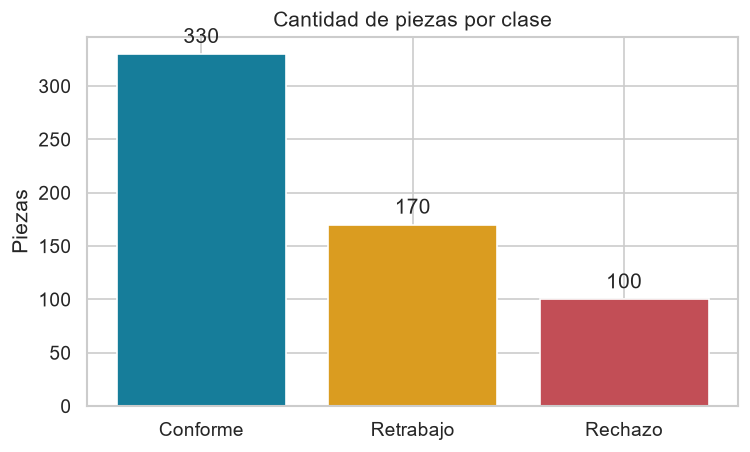

,temperatura_c,vibracion_mm_s,tiempo_ciclo_s
count,600.00,600.00,600.00
mean,66.40,2.36,145.19
std,4.24,0.59,12.86
min,54.62,0.72,110.69
25%,63.64,1.92,136.21
50%,66.16,2.26,144.04
75%,69.31,2.78,153.00
max,77.82,4.29,194.97


In [ ]:
print("Valores faltantes por columna:")
display(datos.isna().sum().to_frame("faltantes"))

conteo_clases = datos["calidad"].value_counts().reindex(CLASES)
display(conteo_clases.to_frame("piezas"))

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(CLASES, conteo_clases, color=[COLORES[c] for c in CLASES])
ax.bar_label(barras, padding=4)
ax.set_title("Cantidad de piezas por clase")
ax.set_ylabel("Piezas")
guardar_figura("01_piezas_por_clase")

display(datos[["temperatura_c", "vibracion_mm_s", "tiempo_ciclo_s"]].describe().round(2))

**Interpretacion sencilla:** la clase Conforme es la más frecuente. Eso ocurre mucho
en manufactura: normalmente hay más piezas buenas que piezas malas. Por eso no basta
con decir "acierte mucho"; también debemos revisar si detecta Retrabajo y Rechazo.

## 5. Visualizar las diferencias entre clases

Ahora veremos si las mediciónes tienen patrones diferentes por clase.

Usaremos diagramás de caja:

- La línea dentro de la caja es el valor central.
- La caja muestra donde cae la parte principal de los datos.
- Los puntos fuera no son automaticamente errores; solo son valores alejados.

Si las cajas están muy separadas, la variable ayuda mucho. Si se enciman, esa variable
no basta por si sola y el modelo tendra que combinarla con otras.

Qué hace el código:

- `variables` lista las columnas numéricas que se gráfican.
- `etiquetas` guarda nombres más claros para los ejes.
- `plt.subplots(1, 3)` crea tres espacios de gráfica en una fila.
- `sns.boxplot` dibuja una caja por clase para cada variable.
- `groupby("calidad").mean()` calcula promedios por grupo.

Qué debe leer el principiante:

- Si Rechazo esta más alto que Conforme en una variable, esa variable ayuda.
- Si las cajas se enciman, habra piezas difíciles de separar.
- La tabla de promedios confirma con numeros lo que se ve en la gráfica.

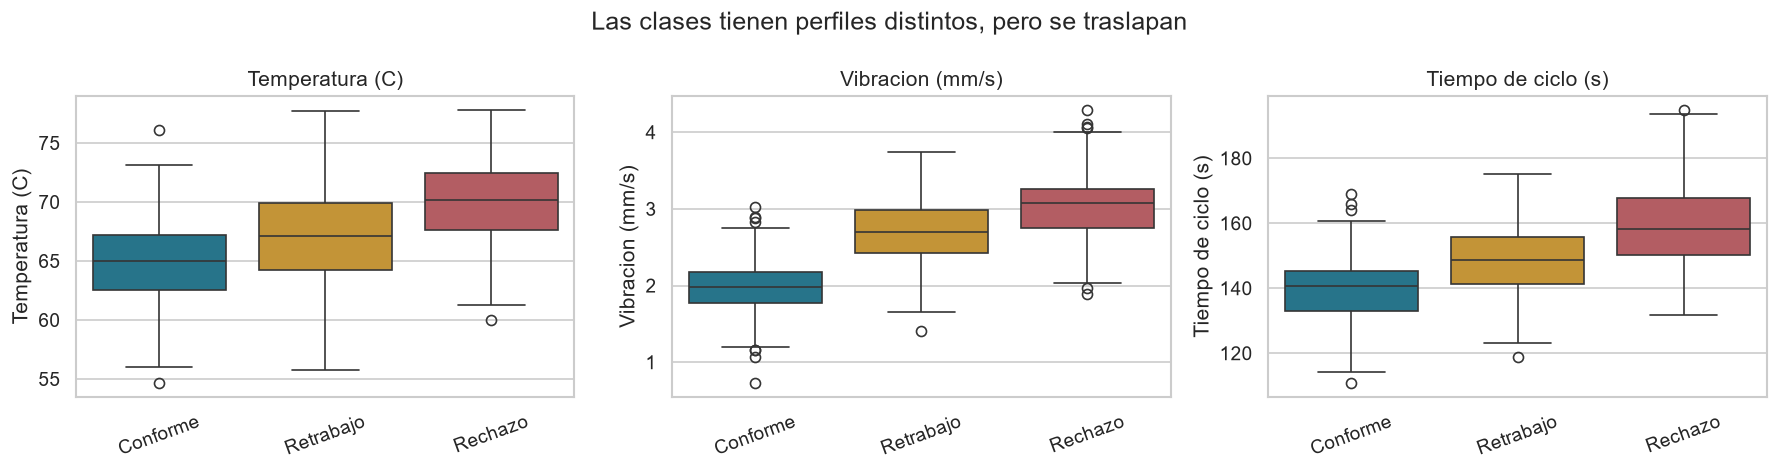

,temperatura_c,vibracion_mm_s,tiempo_ciclo_s
calidad,,,
Conforme,64.95,1.99,139.47
Retrabajo,67.14,2.70,147.97
Rechazo,69.97,3.04,159.35


In [ ]:
variables = ["temperatura_c", "vibracion_mm_s", "tiempo_ciclo_s"]
etiquetas = ["Temperatura (C)", "Vibracion (mm/s)", "Tiempo de ciclo (s)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, variable, etiqueta in zip(axes, variables, etiquetas):
    sns.boxplot(data=datos, x="calidad", y=variable, order=CLASES,
                hue="calidad", hue_order=CLASES, palette=COLORES,
                legend=False, ax=ax)
    ax.set_title(etiqueta)
    ax.set_xlabel("")
    ax.set_ylabel(etiqueta)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Las clases tienen perfiles distintos, pero se traslapan")
fig.tight_layout()
guardar_figura("02_boxplots_por_clase")

promedios = datos.groupby("calidad")[variables].mean().reindex(CLASES).round(2)
display(promedios)

**Interpretacion sencilla:** Rechazo suele tener mayor temperatura, mayor vibración y
mayor tiempo de ciclo. Pero las cajas se traslapan. Eso significa que hay piezas con
mediciónes parecidas aunque terminen en clases distintas. Por eso tendremos aciertos
y errores.

## 6. Separar entrenamiento y prueba

Esta es una de las ideas más importantes del aprendizaje supervisado.

Dividimos los datos en dos partes:

- **Entrenamiento:** el modelo aprende con estas piezas.
- **Prueba:** el modelo no ve estas piezas hasta el final.

Así evitamos evaluar al modelo con las mismás piezas que uso para aprender. Seria como
estudiar con las respuestas del examen en la mano.

`stratify=y` conserva proporciones parecidas de Conforme, Retrabajo y Rechazo en ambas
partes.

Qué hace cada instruccion:

- `X` guarda las columnas que el modelo puede usar para predecir.
- `y` guarda la respuesta correcta histórica.
- `train_test_split` parte la tabla en entrenamiento y prueba.
- `test_size=0.30` reserva 30% para prueba.
- `random_state=SEMILLA` hace que la division sea repetible.
- `stratify=y` conserva proporciones parecidas de las clases.

Qué sale de este bloque:

- `X_train`, `y_train`: piezas para aprender.
- `X_test`, `y_test`: piezas para evaluar al final.

Regla practica: el modelo puede ver entrenamiento, pero prueba debe quedar como examen.

In [ ]:
X = datos[["temperatura_c", "vibracion_mm_s", "tiempo_ciclo_s"]]
y = datos["calidad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA, stratify=y
)

particion = pd.DataFrame({
    "entrenamiento": y_train.value_counts().reindex(CLASES),
    "prueba": y_test.value_counts().reindex(CLASES),
})

display(particion)
print("Piezas para entrenar:", len(X_train))
print("Piezas para probar:", len(X_test))

,entrenamiento,prueba
calidad,,
Conforme,231,99
Retrabajo,119,51
Rechazo,70,30


Piezas para entrenar: 420
Piezas para probar: 180


## 7. Entrenar el modelo LDA

Este bloque crea y entrena el modelo.

Usamos un `Pipeline` con dos pasos:

- `StandardScaler`: pone las variables en una escala comparable. Esto evita que el
  tiempo de ciclo domine solo porque sus numeros son más grandes.
- `LinearDiscriminantAnalysis`: aprende a separar las clases.

`fit(X_train, y_train)` es el momento en que el modelo aprende. Solo usamos los datos
de entrenamiento.

Qué pasa por dentro de `fit`:

- El escalador aprende el promedio y la desviacion de cada variable en entrenamiento.
- LDA calcula el perfil promedio de cada clase.
- LDA calcula como se dispersan las piezas alrededor de esos perfiles.
- LDA obtiene una regla para clasificar piezas nuevas.

Qué no hace este bloque:

- No evalua el desempeno final.
- No debe usar `X_test`.
- No decide si el modelo ya es suficiente para una planta real.

In [ ]:
modelo = Pipeline([
    ("escala", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

modelo.fit(X_train, y_train)
print("Modelo LDA entrenado correctamente.")

Modelo LDA entrenado correctamente.


## 8. Evaluar con datos de prueba

Ahora usamos la parte de prueba, que el modelo no vio durante el entrenamiento.

`predict` genera la clase estimada para cada pieza. Luego calculamos la exactitud,
que significa:

**aciertos / total de piezas probadas**

También calculamos una referencia simple: que pasaria si siempre dijeramos "Conforme",
que es la clase más comun. El modelo debe superar esa referencia para ser util.

Qué hace cada instruccion clave:

- `modelo.predict(X_test)` genera una prediccion para cada pieza de prueba.
- `accuracy_score(y_test, y_pred)` compara respuesta real contra prediccion.
- `idxmax()` encuentra la clase más frecuente en entrenamiento.
- `np.repeat` crea una prediccion simple: repetir siempre esa clase.
- La tabla compara la regla simple contra LDA.

Cómo leer el resultado:

- Si LDA no supera la regla simple, el modelo no esta aportando mucho.
- Si LDA supera la regla simple, las mediciónes contienen informacion util.
- Aun asi, falta revisar que errores comete.

In [ ]:
y_pred = modelo.predict(X_test)

exactitud = accuracy_score(y_test, y_pred)
clase_mas_comun = y_train.value_counts().idxmax()
prediccion_simple = np.repeat(clase_mas_comun, len(y_test))
exactitud_simple = accuracy_score(y_test, prediccion_simple)

tabla_resultados = pd.DataFrame({
    "modelo": ["Regla simple: siempre clase mas comun", "LDA"],
    "exactitud": [exactitud_simple, exactitud],
})

display(tabla_resultados.assign(exactitud=lambda d: (100 * d["exactitud"]).round(1).astype(str) + "%"))

print(f"LDA acerto {sum(y_pred == y_test)} de {len(y_test)} piezas de prueba.")

,modelo,exactitud
0,Regla simple: siempre clase mas comun,55.0%
1,LDA,75.6%


LDA acerto 136 de 180 piezas de prueba.


**Interpretacion sencilla:** la exactitud responde una pregunta basica: de todas las
piezas de prueba, cuántas clasifico bien el modelo. Pero no debemos quedarnos solo con
ese numero, porque una clase frecuente puede esconder errores en clases menos comunes.

## 9. Ver errores con matriz de confusion

La matriz de confusion muestra donde acierta y donde se equivoca el modelo.

Se lee asi:

- Las filas son la clase real.
- Las columnas son la clase predicha.
- La diagonal principal son aciertos.
- Los valores fuera de la diagonal son errores.

En manufactura, un error delicado seria clasificar como Conforme una pieza que realmente
era Rechazo o Retrabajo.

Qué hace cada instruccion clave:

- `confusion_matrix` cuenta combinaciones real/predicho.
- `pd.DataFrame` convierte la matriz en una tabla fácil de leer.
- `sns.heatmap` dibuja la matriz con colores.
- `errores_como_conforme` suma casos de Retrabajo y Rechazo predichos como Conforme.
- `no_conformes` suma todas las piezas reales que no eran Conforme.

Cómo leer una celda:

- Fila "Rechazo", columna "Conforme": rechazos que el modelo dejo pasar como conformes.
- Fila "Conforme", columna "Rechazo": piezas buenas que el modelo mando a rechazo.
- Los dos errores importan, pero no cuestán lo mismo en una planta.

,Conforme,Retrabajo,Rechazo
Conforme,95,4,0
Retrabajo,14,25,12
Rechazo,4,10,16


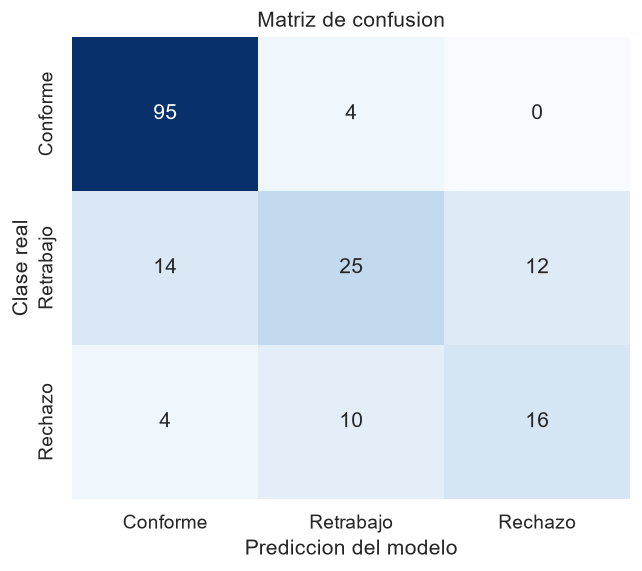

Piezas no conformes clasificadas como Conforme: 18 de 81.


In [ ]:
matriz = confusion_matrix(y_test, y_pred, labels=CLASES)
matriz_df = pd.DataFrame(matriz, index=CLASES, columns=CLASES)
display(matriz_df)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Matriz de confusion")
ax.set_xlabel("Prediccion del modelo")
ax.set_ylabel("Clase real")
guardar_figura("03_matriz_confusion")

errores_como_conforme = matriz_df.loc[["Retrabajo", "Rechazo"], "Conforme"].sum()
no_conformes = matriz_df.loc[["Retrabajo", "Rechazo"]].to_numpy().sum()

print(f"Piezas no conformes clasificadas como Conforme: {errores_como_conforme} de {no_conformes}.")

**Interpretacion sencilla:** los aciertos están en diagonal. Los errores fuera de la
diagonal nos dicen que tipo de confusion tuvo el modelo. Para calidad, conviene poner
especial atencion en las piezas no conformes que el modelo manda a Conforme.

## 10. Revisar resultados por clase

Este bloque muestra métricas por cada clase.

Para principiantes, conviene leer principalmente `recall`:

- Recall de Conforme: de las piezas realmente Conformes, cuántas encontro.
- Recall de Retrabajo: de las piezas realmente de Retrabajo, cuántas encontro.
- Recall de Rechazo: de las piezas realmente de Rechazo, cuántas encontro.

Si el recall de Rechazo es bajo, el modelo deja escapar muchos rechazos.

Diferencia sencilla entre las métricas:

- **Precision:** cuando el modelo dice una clase, que tan seguido tiene razon.
- **Recall o sensibilidad:** de todo lo que realmente era una clase, que tanto encontro.
- **F1:** combina precision y recall en un solo numero.
- **Support:** cuántas piezas reales habia de esa clase en prueba.

En este notebook gráficamos recall porque es muy fácil de explicar:
"de los rechazos reales, cuántos detecte".

In [ ]:
Z_test = modelo.transform(X_test)
grafica = pd.DataFrame(Z_test, columns=["LD1", "LD2"], index=X_test.index)
grafica["clase_real"] = y_test
grafica["prediccion"] = y_pred
grafica["acierto"] = grafica["clase_real"] == grafica["prediccion"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=grafica, x="LD1", y="LD2", hue="clase_real",
                style="acierto", palette=COLORES, s=70, ax=ax)
ax.set_title("Piezas de prueba vistas en los ejes de LDA")
ax.legend(title="Clase real / acierto", bbox_to_anchor=(1.02, 1), loc="upper left")
guardar_figura("05_espacio_lda")

,precision,recall_sensibilidad,f1,piezas_reales
Conforme,0.841,0.960,0.896,99.0
Retrabajo,0.641,0.490,0.556,51.0
Rechazo,0.571,0.533,0.552,30.0


**Interpretacion sencilla:** cuando los puntos de distintas clases se mezclan en la
misma zona, el modelo puede equivocarse. La gráfica ayuda a explicar visualmente por
que el modelo no llega a 100% de acierto.

## 12. Probar piezas nuevas

Ahora simulamos cinco piezas nuevas. Estas piezas no tienen etiqueta real de calidad;
solo queremos ver que predice el modelo.

`predict_proba` entrega probabilidades estimadas. Si una pieza tiene 90% en Rechazo,
el modelo esta bastante inclinado a esa clase. Si las probabilidades están repartidas,
la decisión es más incierta.

En una planta real, estas probabilidades se deberían validar antes de usarlas para
tomar decisiónes automáticas.

Qué hace cada parte:

- `piezas_nuevas` crea casos inventados para probar el modelo.
- `predict_proba` calcula una probabilidad estimada por clase.
- `predict` elige la clase con mayor probabilidad.
- La gráfica apilada muestra como se reparte la confianza del modelo.

Cómo leerlo:

- Una barra casi completa de un color indica decisión clara.
- Una barra repartida entre colores indica incertidumbre.
- Si hay incertidumbre, podría ser una candidata natural para revision manual.

,temperatura_c,vibracion_mm_s,tiempo_ciclo_s,prediccion,probabilidad_mayor
Nueva 1,64,1.9,138,Conforme,0.967
Nueva 2,66,2.4,146,Conforme,0.547
Nueva 3,69,2.8,153,Retrabajo,0.630
Nueva 4,72,3.2,164,Rechazo,0.880
Nueva 5,67,3.0,150,Retrabajo,0.688


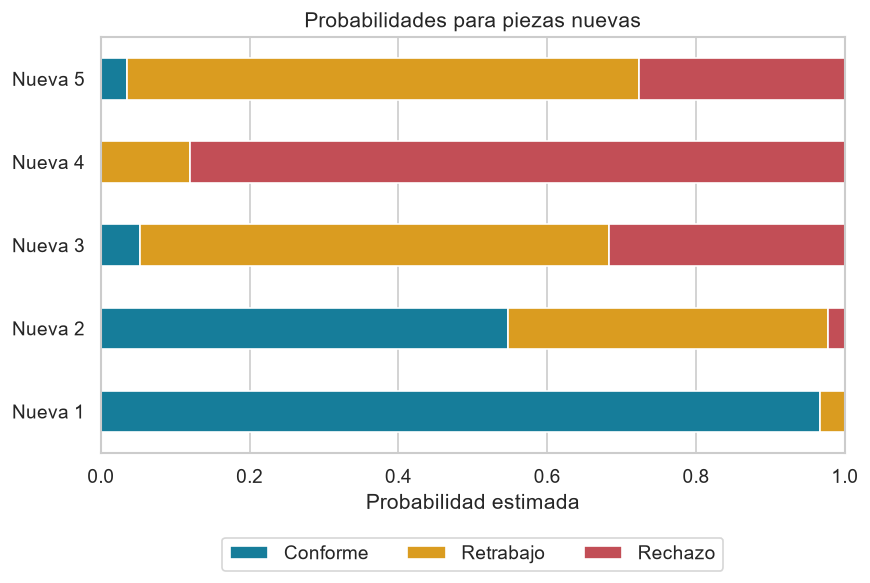

In [ ]:
piezas_nuevas = pd.DataFrame([
    [64, 1.9, 138],
    [66, 2.4, 146],
    [69, 2.8, 153],
    [72, 3.2, 164],
    [67, 3.0, 150],
], columns=["temperatura_c", "vibracion_mm_s", "tiempo_ciclo_s"],
   index=["Nueva 1", "Nueva 2", "Nueva 3", "Nueva 4", "Nueva 5"])

probabilidades = pd.DataFrame(modelo.predict_proba(piezas_nuevas),
                              index=piezas_nuevas.index,
                              columns=modelo.named_steps["lda"].classes_)[CLASES]

resultado_nuevas = piezas_nuevas.copy()
resultado_nuevas["prediccion"] = modelo.predict(piezas_nuevas)
resultado_nuevas["probabilidad_mayor"] = probabilidades.max(axis=1)

display(resultado_nuevas.round(3))

ax = probabilidades.plot(kind="barh", stacked=True, figsize=(8, 4.5),
                         color=[COLORES[c] for c in CLASES])
ax.set_xlim(0, 1)
ax.set_xlabel("Probabilidad estimada")
ax.set_title("Probabilidades para piezas nuevas")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
guardar_figura("06_probabilidades_piezas_nuevas")

## 13. Generar conclusiónes y guardar entregables

Este último bloque resume los resultados con numeros calculados por el notebook.

También guarda:

- los datos simulados,
- las predicciones de prueba,
- las métricas,
- las conclusiónes,
- el modelo entrenado,
- y un archivo ZIP con los resultados.

La conclusión es didáctica: ayuda a entender el flujo de trabajo, pero no autoriza
liberar piezas reales.

Qué se guarda:

- CSV con datos simulados.
- CSV con predicciones de prueba.
- CSV con métricas generales.
- CSV con métricas por clase.
- Markdown con conclusiónes.
- Archivo `.joblib` con el modelo entrenado.
- ZIP con todos los resultados.

Por qué es útil guardar:

- Permite revisar resultados sin volver a correr todo.
- Permite compartir el ejercicio con otra persona.
- Permite comparar ejecuciónes si después se cambia el caso.

In [ ]:
aciertos = int((y_pred == y_test).sum())
total_prueba = len(y_test)
mejora_pp = 100 * (exactitud - exactitud_simple)
errores_como_conforme = int(matriz_df.loc[["Retrabajo", "Rechazo"], "Conforme"].sum())
no_conformes = int(matriz_df.loc[["Retrabajo", "Rechazo"]].to_numpy().sum())
tasa_escape = errores_como_conforme / no_conformes
peor_clase = reporte["recall_sensibilidad"].idxmin()

conclusiones = f"""
## Conclusiones

1. El modelo LDA acertó **{aciertos} de {total_prueba} piezas de prueba**.
   Su exactitud fue **{exactitud:.1%}**.

2. La regla simple de decir siempre **{clase_mas_comun}** logró **{exactitud_simple:.1%}**.
   LDA mejoró esa referencia en **{mejora_pp:.1f} puntos porcentuales**.

3. La clase más difícil para el modelo fue **{peor_clase}**, con un recall de
   **{reporte.loc[peor_clase, "recall_sensibilidad"]:.1%}**.

4. El error más delicado para calidad fue clasificar como Conforme una pieza que
   realmente era Retrabajo o Rechazo. Eso ocurrió en **{errores_como_conforme} de
   {no_conformes} piezas no conformes**, equivalente a **{tasa_escape:.1%}**.

5. La gráfica de LDA muestra que las clases no están perfectamente separadas.
   Por eso el modelo es útil para apoyar revisión o priorización, pero no debe
   reemplazar la inspección sin una validación industrial.

6. Para usar esta técnica con datos reales se necesitarían mediciones históricas
   confiables, etiquetas de calidad independientes, separación por tiempo o lote,
   y criterios claros sobre qué errores son aceptables.
"""

display(Markdown(conclusiones))

predicciones = datos.loc[X_test.index, ["id_pieza", "calidad"]].copy()
predicciones["prediccion_lda"] = y_pred
predicciones["acierto"] = y_pred == y_test.to_numpy()

metricas = pd.DataFrame({
    "metrica": ["exactitud_regla_simple", "exactitud_lda", "escape_no_conformes_a_conforme"],
    "valor": [exactitud_simple, exactitud, tasa_escape],
})

datos.to_csv(CARPETA / "datos_sinteticos.csv", index=False, encoding="utf-8-sig")
predicciones.to_csv(CARPETA / "predicciones_prueba.csv", index=False, encoding="utf-8-sig")
reporte.to_csv(CARPETA / "metricas_por_clase.csv", encoding="utf-8-sig")
metricas.to_csv(CARPETA / "metricas_generales.csv", index=False, encoding="utf-8-sig")
(CARPETA / "conclusiones.md").write_text(conclusiones, encoding="utf-8")
joblib.dump(modelo, CARPETA / "modelo_lda.joblib")

metadatos = {
    "tipo": "Ejercicio didactico con datos sinteticos",
    "fecha": "2026-09-06",
    "filas": len(datos),
    "variables": ["temperatura_c", "vibracion_mm_s", "tiempo_ciclo_s"],
    "clases": CLASES,
    "python": platform.python_version(),
    "scikit_learn": sklearn.__version__,
}
(CARPETA / "metadatos.json").write_text(json.dumps(metadatos, indent=2), encoding="utf-8")

ruta_zip = shutil.make_archive(str(CARPETA), "zip", root_dir=CARPETA)
print("Resultados guardados en:", CARPETA.resolve())
print("ZIP generado:", ruta_zip)


## Conclusiones

1. El modelo LDA acertó **136 de 180 piezas de prueba**.
   Su exactitud fue **75.6%**.

2. La regla simple de decir siempre **Conforme** logró **55.0%**.
   LDA mejoró esa referencia en **20.6 puntos porcentuales**.

3. La clase más difícil para el modelo fue **Retrabajo**, con un recall de
   **49.0%**.

4. El error más delicado para calidad fue clasificar como Conforme una pieza que
   realmente era Retrabajo o Rechazo. Eso ocurrió en **18 de
   81 piezas no conformes**, equivalente a **22.2%**.

5. La gráfica de LDA muestra que las clases no están perfectamente separadas.
   Por eso el modelo es útil para apoyar revisión o priorización, pero no debe
   reemplazar la inspección sin una validación industrial.

6. Para usar esta técnica con datos reales se necesitarían mediciones históricas
   confiables, etiquetas de calidad independientes, separación por tiempo o lote,
   y criterios claros sobre qué errores son aceptables.


Resultados guardados en: C:\Users\baldemar.garza\OneDrive - Xignux Corp\Documentos\ChatGPT\New project\output\analisis_discriminante_manufactura\resultados_lda_manufactura_principiantes
ZIP generado: C:\Users\baldemar.garza\OneDrive - Xignux Corp\Documentos\ChatGPT\New project\output\analisis_discriminante_manufactura\resultados_lda_manufactura_principiantes.zip


## Cómo adaptar este ejercicio a datos reales

Para usarlo en una planta real, cambie el bloque 3 por la lectura de un archivo real,
por ejemplo:

```python
datos = pd.read_csv("mis_datos.csv")
```

La tabla real debería tener una fila por pieza, variables disponibles antes de tomar
la decisión y una etiqueta histórica de calidad. Evite incluir columnas que revelen
el resultado final, como dictamen de inspección, scrap final o costo de rechazo.

Recomendaciones para un caso real:

1. Separe prueba por fecha, lote o turno si las piezas están relacionadas.
2. Revise faltantes, unidades y valores fuera de rango antes de modelar.
3. No use el modelo para liberar producto sin validación con calidad.
4. Defina que error pesa más: falsa alarma o dejar pasar una pieza no conforme.
5. Compare el modelo contra el proceso actual, no solo contra métricas técnicas.

## Preguntas para clase

- Por qué no basta con revisar solo la exactitud?
- Qué error seria más grave en manufactura: llamar Rechazo a una pieza buena o llamar Conforme a una pieza mala?
- Qué significa que dos cajas se traslapen en una gráfica?
- Por qué la prueba debe estar separada del entrenamiento?

## Fuentes para ampliar

- Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*.
  Annals of Eugenics, 7, 179-188. DOI:
  https://doi.org/10.1111/j.1469-1809.1936.tb02137.x.
- Documentacion oficial de scikit-learn sobre LDA y QDA:
  https://scikit-learn.org/stable/modules/lda_qda.html.
- Documentacion oficial de `LinearDiscriminantAnalysis`:
  https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html.

Estas fuentes respaldan la descripción histórica y el uso de la implementación en
scikit-learn. El caso de manufactura del notebook sigue siendo sintético y didáctico.

## Función discriminante de LDA

Al final, LDA toma las mediciónes de una pieza y calcula una puntuación para cada clase.
En este ejercicio hay tres clases, así que el modelo calcula tres puntuaciones:

- una puntuación para **Conforme**,
- una puntuación para **Retrabajo**,
- y una puntuación para **Rechazo**.

La forma sencilla de la función discriminante es:

$$
D_k = b_{0k} + b_{1k}(temperatura) + b_{2k}(vibración) + b_{3k}(tiempo)
$$

Donde:

- \(D_k\) es la puntuación de la clase \(k\).
- \(b_{0k}\) es el punto de partida de esa clase.
- \(b_{1k}\), \(b_{2k}\) y \(b_{3k}\) son pesos aprendidos por el modelo.
- Temperatura, vibración y tiempo son las mediciónes de la pieza.

El modelo calcula esa puntuación para cada clase y elige la clase con la puntuación
más alta.

Dicho de manera simple:

**LDA convierte las mediciónes de una pieza en tres calificaciónes. La calificación
más alta gana.**

Ejemplo conceptual:

| Clase | Puntuación calculada |
|---|---:|
| Conforme | 2.1 |
| Retrabajo | 0.8 |
| Rechazo | -1.4 |

En ese ejemplo, la pieza se clasificaría como **Conforme**, porque 2.1 es la puntuación
más alta.

En `scikit-learn`, esos valores se guardan dentro del modelo:

```python
modelo.named_steps["lda"].coef_       # pesos de las variables
modelo.named_steps["lda"].intercept_  # punto de partida de cada clase
```

En este notebook usamos `StandardScaler` antes de LDA. Por eso, la función discriminante
trabaja con variables estándarizadas: primero se ajustan las escalas de temperatura,
vibración y tiempo; después LDA calcula las puntuaciones. Esto ayuda a que una variable
no domine solo porque se mide con números más grandes.

Para un público principiante, la lectura más importante es esta:

1. Cada variable aporta algo a la puntuación.
2. Cada clase tiene su propia fórmula.
3. La clase con mayor puntuación es la predicción.
4. Si las puntuaciones quedan muy cercanas, la decisión es menos clara.
5. La función discriminante ayuda a clasificar, pero no prueba causalidad.